In [1]:
import numpy as np
import pytreenet as ptn
from copy import deepcopy

In [2]:
from qutip import coherent
def product_state(ttn, bond_dim=2 , physical_dim= 2):
    product_state = deepcopy(ttn)
    A = np.array([1, 0]) 
    #A = np.random.rand(2) + 1j * np.random.rand(2)
    #A = np.array(coherent(physical_dim , alpha).full())
    #A = np.array([1/np.sqrt(2),1/np.sqrt(2)])
    for node_id in product_state.nodes.keys():
        n = product_state.tensors[node_id].ndim - 1
        tensor = A.reshape((1,) * n + (physical_dim,))
        product_state.tensors[node_id] =tensor
        product_state.nodes[node_id].link_tensor(tensor)  
    return product_state

In [3]:
d = 2
shapes = {
    (0, 0): (2, 2, d),
    (0, 1): (2, 2, d),
    (0, 2): (2, 2, d),
    (0, 3): (2, 2, d),
    (0, 4): (2, 2)}

sites = {
    (0, j): ptn.random_tensor_node(shapes[(0, j)], identifier=f"Site({0},{j})") for j in range(5)
}

ttn = ptn.TreeTensorNetworkState()

ttn.add_root(sites[(0, 0)][0], sites[(0, 0)][1])

connections = [
    ((0, 0), (0, 1), 0, 0),
    ((0, 1), (0, 2), 1, 0),
    ((0, 2), (0, 3), 1, 0),
    ((0, 3), (0, 4), 1, 0)]


for (parent, child, parent_leg, child_leg) in connections:
    parent_id = f"Site({parent[0]},{parent[1]})"
    child_id = f"Site({child[0]},{child[1]})"
    ttn.add_child_to_parent(sites[child][0], sites[child][1], child_leg, parent_id, parent_leg)

ttn = product_state(ttn , bond_dim= 10, physical_dim = d)

nodes = {
    (0, j): (ptn.Node(tensor=ttn.tensors[f"Site({0},{j})"].conj() , identifier=f"Node({0},{j})"), ttn.tensors[f"Site({0},{j})"].conj()) for j in range(5)
}

ttn.add_child_to_parent(nodes[(0,0)][0], nodes[(0,0)][1], 1, "Site(0,0)", 1)

connections = [
    ((0, 0), (0, 1), 1, 0),
    ((0, 1), (0, 2), 1, 0),
    ((0, 2), (0, 3), 1, 0),
    ((0, 3), (0, 4), 1, 0)]

for (parent, child, parent_leg, child_leg) in connections:
    parent_id = f"Node({parent[0]},{parent[1]})"
    child_id = f"Node({child[0]},{child[1]})"
    ttn.add_child_to_parent(nodes[child][0], nodes[child][1], child_leg, parent_id, parent_leg)

In [4]:
def get_neighbors_periodic_in_legs(x, y, Lx, Ly):
  neighbors = []
  
  # Only consider up neighbor when Lx is 1
  if Lx > 1:
      # Right neighbor (with periodic boundary)
      right_x = (x + 1) % Lx
      neighbors.append(f"Site({right_x},{y})")
  
  # Up neighbor (with periodic boundary)
  up_y = (y + 1) % Ly
  neighbors.append(f"Site({x},{up_y})")
  
  return neighbors

def get_neighbors_periodic_out_legs(x, y, Lx, Ly):
  neighbors = []
  
  # Only consider up neighbor when Lx is 1
  if Lx > 1:
      # Right neighbor (with periodic boundary)
      right_x = (x + 1) % Lx
      neighbors.append(f"Node({right_x},{y})")
  
  # Up neighbor (with periodic boundary)
  up_y = (y + 1) % Ly
  neighbors.append(f"Node({x},{up_y})")
  
  return neighbors


In [5]:
def Anisotropic_Heisenberg_ham(J_x, J_y, J_z, h_z, Lx, Ly):
    # Get the Pauli matrices
    X, Y, Z = ptn.pauli_matrices()
    
    # Create a conversion dictionary for the operators
    conversion_dict = {
        "X": X,
        "J_x * X": J_x * X,
        "Y": Y,
        "J_y * Y": J_y * Y,
        "Z": Z,
        "J_z * Z": J_z * Z,
        "I2": np.eye(2),
        "h_z * Z": h_z * Z
    }
    
    terms = []
    
    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Site({x},{y})"
            neighbors = get_neighbors_periodic_in_legs(x, y, Lx, Ly)
            
            for neighbor in neighbors:
                terms.append(ptn.TensorProduct({current_site: "X", neighbor: "J_x * X"}))
                terms.append(ptn.TensorProduct({current_site: "Y", neighbor: "J_y * Y"}))
                terms.append(ptn.TensorProduct({current_site: "Z", neighbor: "J_z * Z"}))               

    
    # On-site magnetic field terms
    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Site({x},{y})"
            terms.append(ptn.TensorProduct({current_site: "h_z * Z"}))
    
    return ptn.Hamiltonian(terms, conversion_dict)

In [6]:
def Liouville_Heisenberg(Lx, Ly, J_x, J_y, J_z, h_z, L, gamma):
    # Get the Pauli matrices
    X, Y, Z = ptn.pauli_matrices()
    # Create the conversion dictionary for the Hamiltonian.
    conversion_dict = {
        "-iJ_x * X": -1j*J_x * (X),
        "X":                   (X),
        "-iJ_Y * Y": -1j*J_y * (Y),
        "Y":                   (Y),
        "-iJ_z * Z": -1j*J_z * (Z),
        "Z":                   (Z),
        "-ih_z * Z": -1j*h_z * (Z),

        "iJ_x * X.T": 1j*J_x * (X.T),
        "X.T":                 (X.T),
        "iJ_Y * Y.T": 1j*J_y * (Y.T),
        "Y.T":                 (Y.T),
        "iJ_z * Z.T": 1j*J_z * (Z.T),
        "Z.T":                 (Z.T),
        "ih_z * Z.T": 1j*h_z * (Z.T),

        "L": np.sqrt(gamma) * L,
        "L^dagger.T":  np.sqrt(gamma) * L.conj(),
        "-1/2 (L^dagger @ L)": -1/2 * gamma * (L.conj().T @ L),
        "-1/2 (L^dagger @ L).T": -1/2 * gamma * (L.conj().T @ L).T,

        "I2": np.eye(2),
    }
    
    terms = []
    
    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Site({x},{y})"
            neighbors = get_neighbors_periodic_in_legs(x, y, Lx, Ly)
            for neighbor in neighbors:
                terms.append(ptn.TensorProduct({current_site: "-iJ_x * X", neighbor: "X"}))
                terms.append(ptn.TensorProduct({current_site: "-iJ_Y * Y", neighbor: "Y"}))
                terms.append(ptn.TensorProduct({current_site: "-iJ_z * Z", neighbor: "Z"})) 

    # On-site magnetic field terms
    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Site({x},{y})"
            terms.append(ptn.TensorProduct({current_site: "-ih_z * Z"}))
        
    # Hopping terms for the transpose
    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Node({x},{y})"
            neighbors = get_neighbors_periodic_out_legs(x, y, Lx, Ly)
            
            for neighbor in neighbors:
                terms.append(ptn.TensorProduct({current_site: "iJ_x * X.T", neighbor: "X.T"}))
                terms.append(ptn.TensorProduct({current_site: "iJ_Y * Y.T", neighbor: "Y.T"}))
                terms.append(ptn.TensorProduct({current_site: "iJ_z * Z.T", neighbor: "Z.T"}))                

    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Node({x},{y})"
            terms.append(ptn.TensorProduct({current_site: "ih_z * Z.T"}))

    for x in range(Lx):
        for y in range(Ly):
            out_site = f"Node({x},{y})"
            in_site = f"Site({x},{y})"
            terms.append(ptn.TensorProduct({in_site: "L" , out_site: "L^dagger.T"}))
            terms.append(ptn.TensorProduct({in_site: "-1/2 (L^dagger @ L)"}))
            terms.append(ptn.TensorProduct({out_site: "-1/2 (L^dagger @ L).T"}))

    H1 = ptn.Hamiltonian(terms, conversion_dict)
    
    return H1

In [7]:
def Magnetization_op_total(Lx, Ly):
    # Get the Pauli matrices
    X, Y, Z = ptn.pauli_matrices()
    # Create a conversion dictionary for the operators
    conversion_dict = {
        "X": X ,
        "Y": Y,
        "Z": Z ,
        "I2": np.eye(2)}
    for dim in range(1, 200):
        conversion_dict[f"I{dim}"] = np.eye(dim)        
    terms = []
    for x in range(Lx):
        for y in range(Ly):
            current_site = f"Vertex({x},{y})"
            terms.append(ptn.TensorProduct({current_site: "Z"}))  # Using Z for magnetization

    return ptn.Hamiltonian(terms, conversion_dict)

In [8]:
X , Y , Z = ptn.pauli_matrices()

Lx =  1
Ly  = 5
J_x = 0.1
J_y = 0.3
J_z = 0.5
h_z = 0
gamma = 0.7
L = (X - 1j * Y) / 2

ket , bra = ptn.devectorize_pho_1d(ttn , connections, 5)


# TTNO : Hamiltonian acting on in_legs
H1 = Anisotropic_Heisenberg_ham(J_x, J_y, J_z, h_z, Lx, Ly)
H1 = H1.pad_with_identities(ttn, symbolic= True)
H = ptn.TTNO.from_hamiltonian(H1, ttn)

# TTNO : Liouville operator 
H1 = Liouville_Heisenberg(Lx, Ly, J_x, J_y, J_z, h_z, L, gamma)
H1 = H1.pad_with_identities(ttn , symbolic= True)
L_fancy = ptn.TTNO.from_hamiltonian(H1, ttn)

M = Magnetization_op_total(Lx, Ly)
M = M.pad_with_identities(ket, symbolic= True)
M = ptn.TTNO.from_hamiltonian(M, ket)

# ttn = ptn.normalize_ttn_Lindblad_4(ttn , 'Node(2,3)')
I = ptn.TTNO.Identity(ttn)


In [9]:
#vectorized_pho = ptn.normalize_ttn_Lindblad_XX(ttn, "Site(0,0)","Node(0,0)")
tdvp_Lindblad = ptn.SecondOrderOneSiteTDVP(initial_state = ttn,
                                            hamiltonian = L_fancy,
                                            time_step_size = 0.001,
                                            final_time = 0.1,
                                            operators = M,
                                            connections = [
                                                        ((0, 0), (0, 1), 1, 0),
                                                        ((0, 1), (0, 2), 1, 0),
                                                        ((0, 2), (0, 3), 1, 0),
                                                        ((0, 3), (0, 4), 1, 0)])

In [10]:
tdvp_Lindblad.run_Lindblad(evaluation_time=1)
times = tdvp_Lindblad.times()


KeyError: 'Site(1,0)'

In [24]:
from qutip import *
import numpy as np

# Define coupling constants for anisotropy
Jx = 0.1  # Coupling in x-direction
Jy = 0.3 # Coupling in y-direction
Jz = 0.5  # Coupling in z-direction

gamma_relax = 0.7 # Relaxation rate
# gamma_dephase = 1  # Dephasing rate

# Number of spins in the chain
N = 5

# Precompute the spin operators for each site
sx_list = []
sy_list = []
sz_list = []
sigmam_list = []

si = qeye(2)  # Identity operator for a single qubit
for n in range(N):
    # List of identity operators for all sites
    op_list = [si] * N
    # Sx operator at site n
    op_list[n] = sigmax()
    sx = tensor(op_list)
    sx_list.append(sx)
    
    # Sy operator at site n
    op_list[n] = sigmay()
    sy = tensor(op_list)
    sy_list.append(sy)
    
    # Sz operator at site n
    op_list[n] = sigmaz()
    sz = tensor(op_list)
    sz_list.append(sz)
    
    # S- (lowering) operator at site n
    op_list[n] = sigmam()
    sigmam_op = tensor(op_list)
    sigmam_list.append(sigmam_op)

# Initialize the Hamiltonian
H = 0

# Build the Hamiltonian for a 1D chain with nearest-neighbor interactions and periodic boundary conditions
for n in range(N):
    # Interaction terms with the next neighbor (with periodic boundary)
    next_n = (n + 1) % N
    H += Jx * sx_list[n] * sx_list[next_n]
    H += Jy * sy_list[n] * sy_list[next_n]
    H += Jz * sz_list[n] * sz_list[next_n]

# Option 1: All spins up |00000> (Eigenstate of Sz_total)
psi0 = tensor([basis(2, 0) for _ in range(N)]).unit()

# Option 2: All spins in superposition |+⟩ = (|0⟩ + |1⟩)/sqrt(2)
# psi0 = tensor([(basis(2, 0) + basis(2, 1)).unit() for _ in range(N)])

# Option 3: Half spins excited |11100>
# psi0 = tensor([basis(2, 1) if n < N//2 else basis(2, 0) for n in range(N)]).unit()

# Define collapse operators (for the Lindblad equation)
c_ops = []

for n in range(N):
    # Relaxation (spin flip down) using lowering operator S-
    c_ops.append(np.sqrt(gamma_relax) * sigmam_list[n])
    
    # Optional: Dephasing using Sz operator
    # Uncomment the following line if you wish to include dephasing
    # c_ops.append(np.sqrt(gamma_dephase) * sz_list[n])

# Time points where we want the solution
total_time = 0.1  # Total time in seconds
time_step = 0.001  # Time step in seconds

# Create the time list
tlist = np.arange(0, total_time + time_step, time_step)  # Include the endpoint

# Observables to calculate - total magnetization in z-direction
sz_total = sum(sz_list)

# Individual spin observables
sz_individual = sz_list

# Solve the master equation
result = mesolve(
    H,        # Hamiltonian
    psi0,     # Initial state
    tlist,    # Time list
    c_ops,    # Collapse operators
    [sz_total] + sz_individual  # List of observables
)

# Extract expectation values
magnetization_z = result.expect[0]
individual_sz = result.expect[1:]  # List of expectation values for each spin

# You can now plot or analyze the results as needed

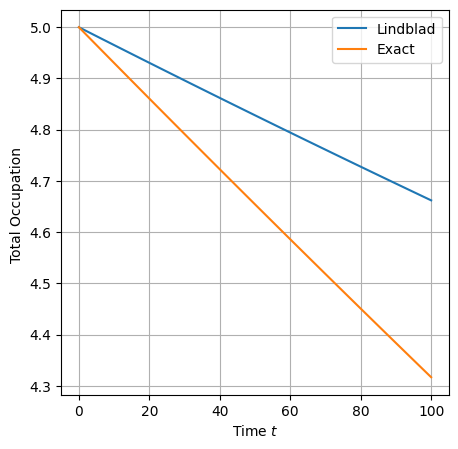

In [25]:
import matplotlib.pyplot as plt

fig1, axs1 = plt.subplots(1, 1, sharex=True, figsize=(5, 5))

axs1.plot( tdvp_Lindblad.operator_results()[0] , label="Lindblad")

axs1.plot( magnetization_z , label="Exact")

axs1.set_xlabel("Time $t$")
axs1.set_ylabel("Total Occupation ")
axs1.grid(True)
axs1.legend()

In [26]:
sigmam() , L

(Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=False
 Qobj data =
 [[0. 0.]
  [1. 0.]],
 array([[0.+0.j, 0.+0.j],
        [1.+0.j, 0.+0.j]]))